In [1]:
import sys
sys.path.append('../')
import UTILS.utils as utils

import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import CountVectorizer
from sklearn import decomposition
import pandas as pd
import re
import spacy
import gensim
from itertools import combinations

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import gensim.corpora as corpora
from gensim.models import CoherenceModel
from tqdm import tqdm


## TOPIC MODELLING WITH NON-NEGATIVE MATRIX FACTORIZATION

In [2]:
# vectorizer using tf-idf
tfidf_vectorizer = TfidfVectorizer(
    max_df=0.95, # Ignore terms that appear in more than 95% of documents
    min_df=2,    # Ignore terms that appear in less than 2 documents
    stop_words='english',
    ngram_range=(1, 2) # Consider unigrams and bigrams
)

# get top terms for topic
def get_descriptor( all_terms, H, topic_index, top ):
    top_indices = np.argsort( H[topic_index,:] )[::-1]
    top_terms = []
    for term_index in top_indices[0:top]:
        top_terms.append( all_terms[term_index] )
    return top_terms

# get coherence
def get_coherence(topics, tokenized_documents, dictionary):
    overall_coherence_model = CoherenceModel(
    topics=topics, # All top word lists from NMF topics
    texts=tokenized_documents,       # Original tokenized documents
    dictionary=dictionary,           # Gensim dictionary
    coherence='c_v'                  # Common coherence type
    )
    return overall_coherence_model.get_coherence()

def preprocess_text_for_gensim(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text) # Remove non-alphabetic chars
    tokens = text.split()
    tokens = [word for word in tokens if word not in ENGLISH_STOP_WORDS and len(word) > 1]
    return tokens

In [3]:
# parameters to test
num_topics = range(10, 30, 2)
init = ["random", "nndsvd", "nndsvda", "nndsvdar"]
params = [(x, y) for x in num_topics for y in init]

In [4]:
def test_hyperparams(X, feature_names, dictionary, tokenized_documents):
    all_rows = []
    for param in tqdm(params):
            topic = param[0]
            init_ver = param[1]
            nmf_model = NMF(n_components=topic, init=init_ver, random_state=100)
            nmf_model.fit(X)
            H = nmf_model.components_
            term_rankings = []
            for topic_index in range(topic):
                term_rankings.append( get_descriptor( feature_names, H, topic_index, 10 ) )
            coherence = get_coherence(term_rankings, tokenized_documents,dictionary)
            all_rows.append([topic, init_ver, coherence])
    return all_rows


## SENTENCES

In [5]:
all_sentences = pd.read_csv(utils.ALL_SENTENCES_DF)
df = pd.DataFrame(all_sentences, columns=["text"])

# prepare necessary elements

documents = all_sentences["text"].to_list() # documents
tfidf = tfidf_vectorizer.fit_transform(documents) # tf-idf
feature_names = tfidf_vectorizer.get_feature_names_out() # tf-idf feature names

# tokenized documents, dict and corpus for NMF
tokenized_documents = [preprocess_text_for_gensim(doc) for doc in documents]
dictionary = corpora.Dictionary(tokenized_documents)

In [ ]:
all_rows = test_hyperparams(tfidf, feature_names, dictionary, tokenized_documents)
hyperparams_df = pd.DataFrame(all_rows, columns=["num_topics", "init", "coherence"])
hyperparams_df.to_csv("../../Data/HYPERPARAMS/NMF_sentences.csv")

In [15]:
hyperparams_df = pd.read_csv("../../Data/HYPERPARAMS/NMF_sentences.csv")

In [16]:
max = hyperparams_df[["coherence"]].idxmax()
hyperparams_df.iloc[max]

,Unnamed: 0,num_topics,init,coherence
5,5,12,nndsvd,0.554751


In [9]:
nmf = NMF(n_components=12, solver="cd", beta_loss="frobenius", init="nndsvd")
W = nmf.fit_transform(tfidf)
H = nmf.components_

for i, topic in enumerate(H):
     s = "\item" + "\\" + "v" + "space{-0.2cm}["
     print(s + ", ".join([str(x) for x in feature_names[topic.argsort()[-8:]]]) + "]")

<>:6: SyntaxWarning: invalid escape sequence '\i'
<>:6: SyntaxWarning: invalid escape sequence '\i'
/var/folders/yl/114pstb53sj0y8fd5bqt753r0000gn/T/ipykernel_85636/3917936364.py:6: SyntaxWarning: invalid escape sequence '\i'
  s = "\item" + "\\" + "v" + "space{-0.2cm}["


\item\vspace{-0.2cm}[shall, direction, european settlement, european, settlement, city, native city, native]
\item\vspace{-0.2cm}[lines connected, connected number, branch, number, red lines, lines, red, map]
\item\vspace{-0.2cm}[day, world, little, feet, time, small, tea, china]
\item\vspace{-0.2cm}[ketteler street, legation street, distance, von ketteler, von, ketteler, legation, street]
\item\vspace{-0.2cm}[arsenal, battle, 1900, pekin, tsin pekin, tien tsin, tsin, tien]
\item\vspace{-0.2cm}[chinese empire, foreign, chinese city, men, empire, women, years, chinese]
\item\vspace{-0.2cm}[passed, line, left, mud wall, brick, mud, feet, wall]
\item\vspace{-0.2cm}[coal, imperial, hill, pekin, palace, forbidden city, forbidden, city]
\item\vspace{-0.2cm}[north, chien gate, ha, directly, chien, south gate, south, gate]
\item\vspace{-0.2cm}[left, taku, fort, boats, pei ho, pei, ho, river]
\item\vspace{-0.2cm}[lies, reached, distant, thousand miles, thousand, miles away, away, miles]
\item\v

In [19]:
## CREATING GRAPH
document_topic_assignments = np.argmax(W, axis=1)
topic_counts = pd.DataFrame(document_topic_assignments).value_counts().sort_index()
topic_labels = [f"{i}" for i in range(12)]
topic_counts.index = topic_labels


In [20]:
topic_counts_sorted = topic_counts.sort_values(ascending=False)
df_plot = topic_counts_sorted.reset_index()
df_plot.columns = ['Topic', 'Number of Documents']

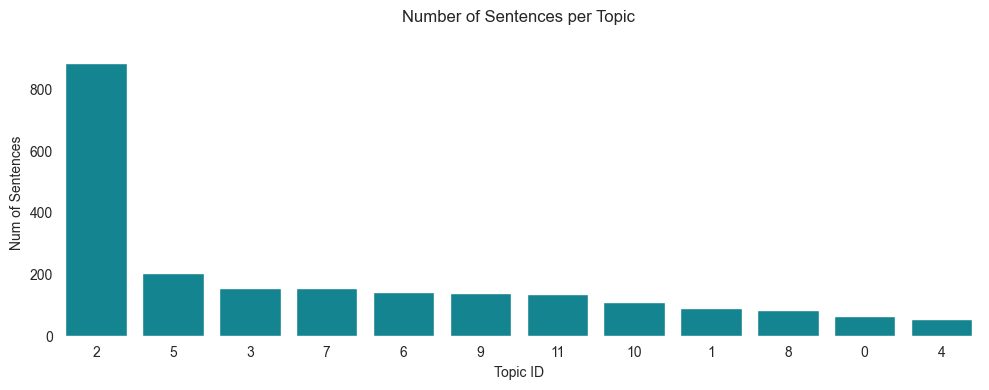

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Bitstream Vera Sans', 'Arial', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans']

sns.set_style("white") 
plt.figure(figsize=(10, 4)) 

ax = sns.barplot(x='Topic', y='Number of Documents', data=df_plot,
                 #order=topic_order,
                 color='#0094a6') 

plt.xlabel('Topic ID') 
sns.despine(left=True, bottom=True, top=True, right=True)
ax.axhline(0, color='gray', linewidth=0.5, zorder=0)
plt.ylabel('Num of Sentences')
ax.yaxis.set_tick_params(length=0) 
ax.xaxis.set_tick_params(length=4, color='gray') 
plt.title('Number of Sentences per Topic', pad=20)

plt.tight_layout()
plt.show()

## PARAGRAPHS

In [6]:
all_paragraphs = pd.read_csv("../../Data/TEXT/ALL_PARAGRAPHS.csv")
df = pd.DataFrame(all_paragraphs, columns=["text"])

In [8]:
documents_para = all_paragraphs["text"].to_list()
tfidf_para = tfidf_vectorizer.fit_transform(documents_para)
feature_names_para = tfidf_vectorizer.get_feature_names_out()

In [11]:
tokenized_documents_para = [preprocess_text_for_gensim(doc) for doc in documents_para]
dictionary_para = corpora.Dictionary(tokenized_documents_para)

In [ ]:
all_rows_para = test_hyperparams(tfidf_para, feature_names_para, dictionary_para, tokenized_documents_para)
hyperparams_df = pd.DataFrame(all_rows_para, columns=["num_topics", "init", "coherence"])
hyperparams_df.to_csv("../../Data/HYPERPARAMS/NMF_paragraphs.csv")

In [13]:
hyperparams_df = pd.read_csv("../../Data/HYPERPARAMS/NMF_paragraphs.csv")
max = hyperparams_df[["coherence"]].idxmax()
hyperparams_df.iloc[max]

,Unnamed: 0,num_topics,init,coherence
4,4,12,random,0.539747
